# Exoplanetas

## Importación
Después de encontrar los datos en la página de la NASA y hacer el query requerido imprimimos el dataset para asegurarnos que la información se cargó de forma correcta.

In [19]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/raw/exoplanets_raw.csv")
df.shape

(6333, 15)

In [4]:
df.head()
# Abrimos el dataset para leer de forma rápida las columnas y los datos.

,pl_name,hostname,discoverymethod,disc_year,disc_facility,pl_orbper,pl_orbsmax,pl_rade,pl_bmasse,pl_orbeccen,pl_eqt,st_teff,st_rad,st_mass,sy_dist
0,XO-2 S d,XO-2 S,Radial Velocity,2024,Multiple Observatories,4696.000000,5.46000,13.000000,1179.143390,0.091,110.98,5325.0,1.020,0.980000,151.398
1,Kepler-1808 b,Kepler-1808,Transit,2021,Kepler,23.340401,0.14670,3.025113,9.400000,0.000,601.00,5530.0,0.892,0.773000,1022.010
2,Kepler-418 b,Kepler-418,Transit,2014,Kepler,86.678560,0.39249,13.450000,349.611248,0.200,434.00,5820.0,1.090,0.980000,1002.530
3,Kepler-249 d,Kepler-249,Transit,2014,Kepler,15.368459,0.09700,1.570000,3.090000,0.000,332.00,3568.0,0.482,0.510238,190.401
4,OGLE-2017-BLG-0364L b,OGLE-2017-BLG-0364L,Microlensing,2024,OGLE,NaN,3.79000,10.300000,75.800000,NaN,NaN,NaN,NaN,0.490000,7860.000


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6333 entries, 0 to 6332
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   pl_name          6333 non-null   str    
 1   hostname         6333 non-null   str    
 2   discoverymethod  6333 non-null   str    
 3   disc_year        6333 non-null   int64  
 4   disc_facility    6333 non-null   str    
 5   pl_orbper        5989 non-null   float64
 6   pl_orbsmax       5906 non-null   float64
 7   pl_rade          6283 non-null   float64
 8   pl_bmasse        6302 non-null   float64
 9   pl_orbeccen      5280 non-null   float64
 10  pl_eqt           5808 non-null   float64
 11  st_teff          6036 non-null   float64
 12  st_rad           6012 non-null   float64
 13  st_mass          6324 non-null   float64
 14  sy_dist          6306 non-null   float64
dtypes: float64(10), int64(1), str(4)
memory usage: 742.3 KB


## Limpieza

In [6]:
(df.isna().sum() / len(df) * 100).sort_values(ascending=False)

pl_orbeccen        16.627191
pl_eqt              8.289910
pl_orbsmax          6.742460
pl_orbper           5.431865
st_rad              5.068688
st_teff             4.689721
pl_rade             0.789515
pl_bmasse           0.489499
sy_dist             0.426338
st_mass             0.142113
disc_year           0.000000
pl_name             0.000000
disc_facility       0.000000
hostname            0.000000
discoverymethod     0.000000
dtype: float64

In [7]:
df["disc_year"] = df["disc_year"].astype("Int64")  # Int64 con mayúscula permite nulos
df["discoverymethod"] = df["discoverymethod"].astype("category")
df["disc_facility"] = df["disc_facility"].astype("category")

In [8]:
df[["pl_bmasse", "pl_rade", "pl_orbper", "pl_orbeccen"]].describe()

,pl_bmasse,pl_rade,pl_orbper,pl_orbeccen
count,6302.000000,6283.000000,5.989000e+03,5280.000000
mean,404.629002,5.852218,7.148041e+04,0.079765
std,1140.059790,5.424010,5.196992e+06,0.152838
min,0.020000,0.309800,9.070629e-02,0.000000
25%,4.310000,1.846994,4.307440e+00,0.000000
50%,9.320000,2.860000,1.074000e+01,0.000000
75%,189.856433,11.943169,3.855830e+01,0.092000
max,9534.852210,87.205870,4.020000e+08,0.950000


In [9]:
import pathlib

out_path = pathlib.Path("../data/processed/exoplanets_clean.csv")
out_path.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(out_path, index=False)
print(f"Guardado en {out_path}")

Guardado en ..\data\processed\exoplanets_clean.csv


## Análisis
Cargamos la librerias necesarias para realizar el análisis estadístico y las diferentes pruebas.

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

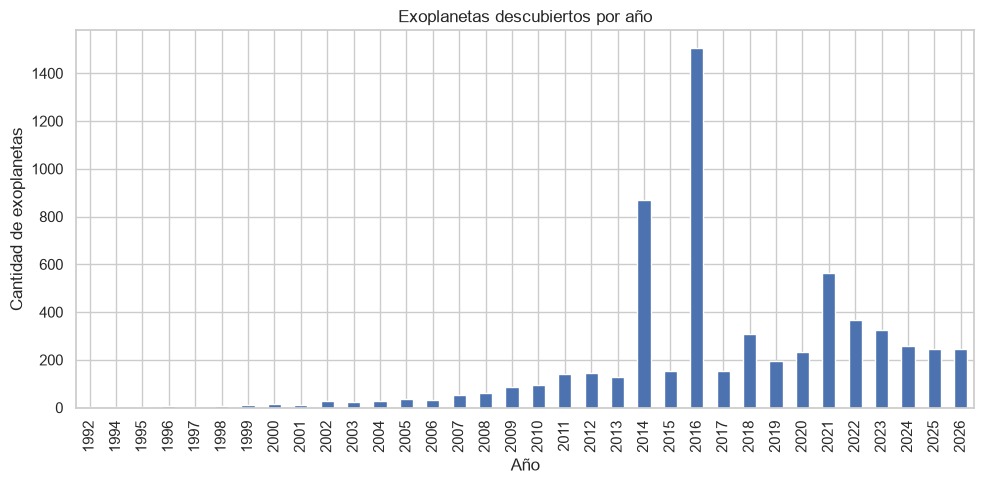

In [32]:
plt.figure(figsize=(10, 5))
df["disc_year"].value_counts().sort_index().plot(kind="bar")
plt.title("Exoplanetas descubiertos por año")
plt.xlabel("Año")
plt.ylabel("Cantidad de exoplanetas")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("../images/descubrimientos_por_año.png", dpi=150, bbox_inches="tight")
plt.show()

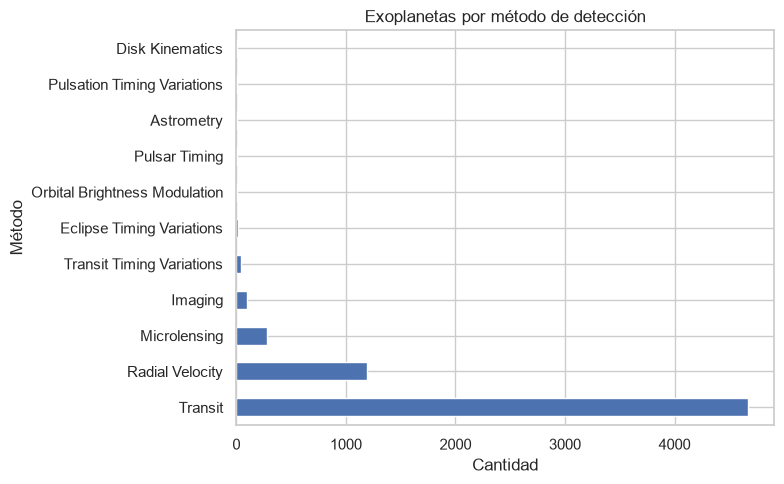

In [33]:
plt.figure(figsize=(8, 5))
df["discoverymethod"].value_counts().plot(kind="barh")
plt.title("Exoplanetas por método de detección")
plt.xlabel("Cantidad")
plt.ylabel("Método")
plt.tight_layout()
plt.savefig("../images/metodos_deteccion.png", dpi=150, bbox_inches="tight")
plt.show()

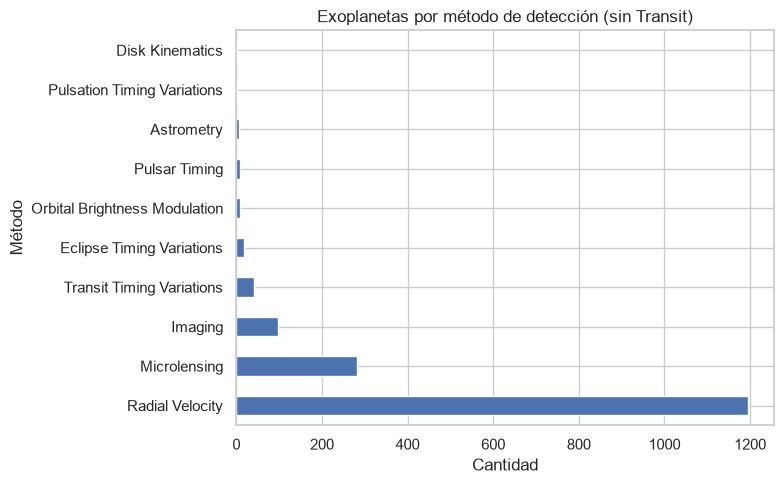

In [35]:
counts_no_transit = df[df["discoverymethod"] != "Transit"]["discoverymethod"].value_counts()

plt.figure(figsize=(8, 5))
counts_no_transit.plot(kind="barh")
plt.title("Exoplanetas por método de detección (sin Transit)")
plt.xlabel("Cantidad")
plt.ylabel("Método")
plt.tight_layout()
plt.savefig("../images/metodos_sin_transit.png", dpi=150, bbox_inches="tight")
plt.show()

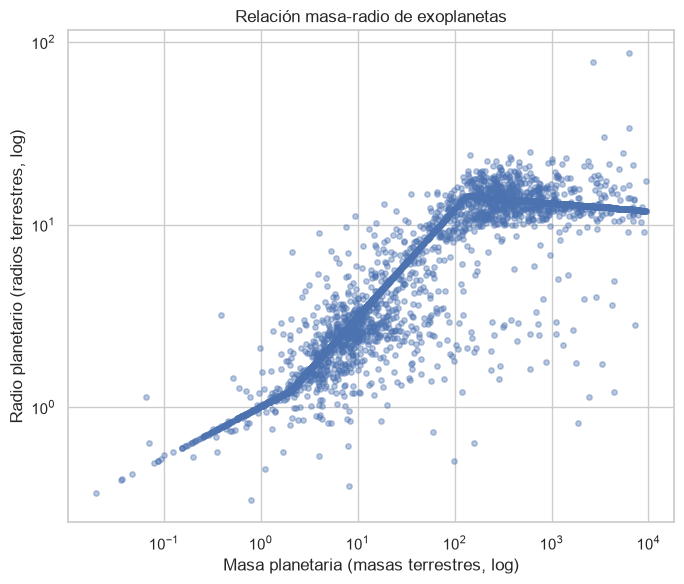

In [36]:
plt.figure(figsize=(7, 6))
plt.scatter(df["pl_bmasse"], df["pl_rade"], alpha=0.4, s=15)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Masa planetaria (masas terrestres, log)")
plt.ylabel("Radio planetario (radios terrestres, log)")
plt.title("Relación masa-radio de exoplanetas")
plt.tight_layout()
plt.savefig("../images/relacion_masa_radio.png", dpi=150, bbox_inches="tight")
plt.show()

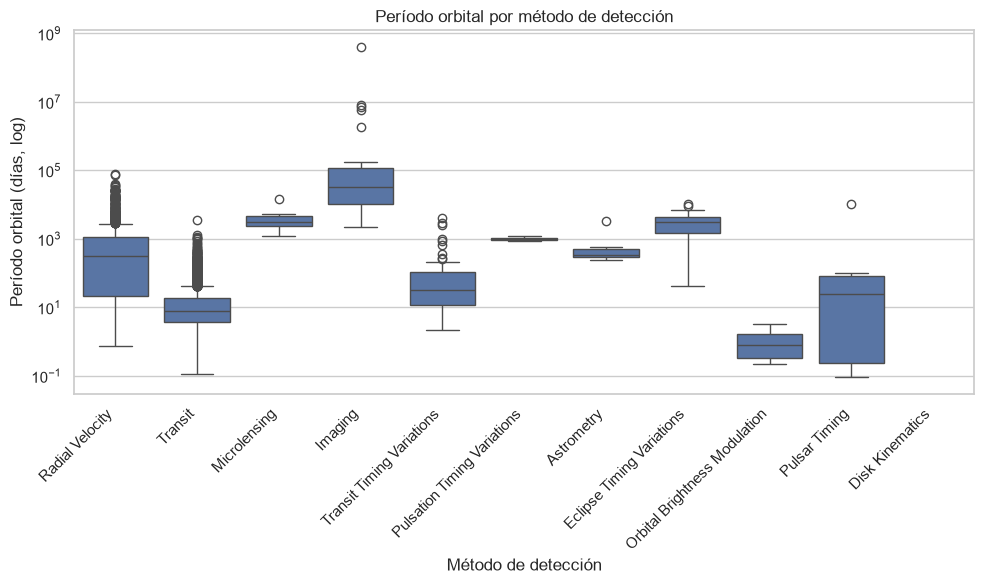

In [37]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="discoverymethod", y="pl_orbper")
plt.yscale("log")
plt.title("Período orbital por método de detección")
plt.xlabel("Método de detección")
plt.ylabel("Período orbital (días, log)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../images/boxplot_metodo_periodo.png", dpi=150, bbox_inches="tight")
plt.show()

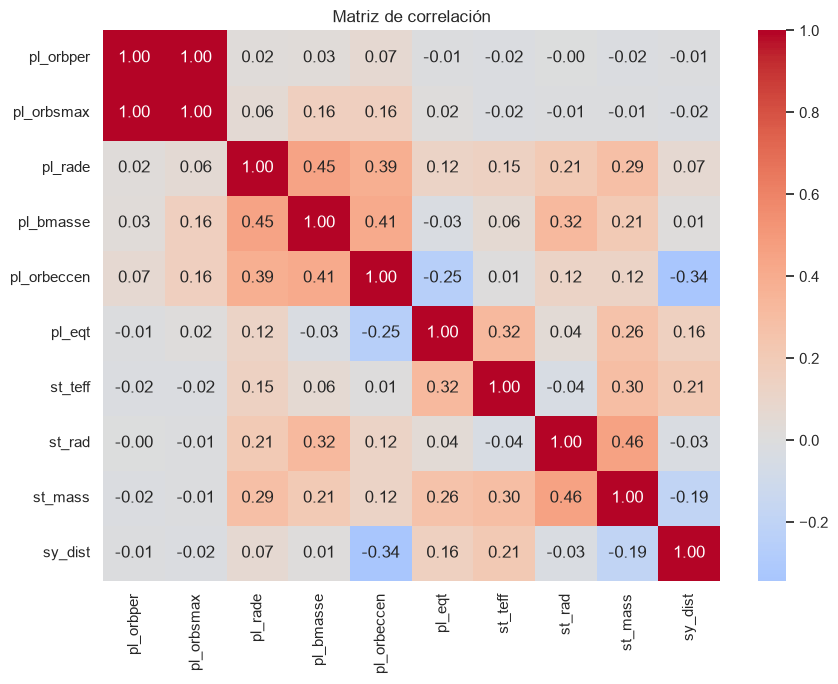

In [40]:
numeric_cols = ["pl_orbper", "pl_orbsmax", "pl_rade", "pl_bmasse", "pl_orbeccen", "pl_eqt", "st_teff", "st_rad", "st_mass", "sy_dist"]

corr = df[numeric_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlación")
plt.tight_layout()
plt.savefig("../images/matriz_correlacion.png", dpi=150, bbox_inches="tight")
plt.show()

## Pruebas estadísticas

In [16]:
from scipy import stats

corr_spearman, p_value = stats.spearmanr(df["pl_bmasse"], df["pl_rade"], nan_policy="omit")
print(f"Correlación de Spearman (masa vs radio): {corr_spearman:.3f}")
print(f"p-valor: {p_value:.2e}")

Correlación de Spearman (masa vs radio): 0.930
p-valor: 0.00e+00


In [22]:
# Revisar cuántos planetas tiene cada método
print(df["discoverymethod"].value_counts())

discoverymethod
Transit                          4674
Radial Velocity                  1196
Microlensing                      282
Imaging                            98
Transit Timing Variations          40
Eclipse Timing Variations          17
Orbital Brightness Modulation       9
Pulsar Timing                       8
Astrometry                          6
Pulsation Timing Variations         2
Disk Kinematics                     1
Name: count, dtype: int64


In [23]:
conteo_metodos = df["discoverymethod"].value_counts()
metodos_validos = conteo_metodos[conteo_metodos >= 5].index

df_filtrado = df[df["discoverymethod"].isin(metodos_validos)]

groups = [group["pl_orbper"].dropna() for name, group in df_filtrado.groupby("discoverymethod")]
h_stat, p_value = stats.kruskal(*groups)
print(f"Estadístico H: {h_stat:.2f}")
print(f"p-valor: {p_value:.2e}")

Estadístico H: 1552.06
p-valor: 0.00e+00


In [20]:
mask = (df["pl_bmasse"] > 0) & (df["pl_rade"] > 0)
log_mass = np.log10(df.loc[mask, "pl_bmasse"])
log_radius = np.log10(df.loc[mask, "pl_rade"])

slope, intercept, r_value, p_value, std_err = stats.linregress(log_mass, log_radius)
print(f"Pendiente (exponente k): {slope:.3f}")
print(f"R²: {r_value**2:.3f}")
print(f"p-valor: {p_value:.2e}")

Pendiente (exponente k): 0.355
R²: 0.842
p-valor: 0.00e+00


In [21]:
tabla_contingencia = pd.crosstab(df["disc_facility"], df["discoverymethod"])
chi2, p_value, dof, expected = stats.chi2_contingency(tabla_contingencia)
print(f"Chi²: {chi2:.2f}")
print(f"p-valor: {p_value:.2e}")
print(f"Grados de libertad: {dof}")

Chi²: 30723.14
p-valor: 0.00e+00
Grados de libertad: 720


Para dar una respuesta más clara sobre la relación de masa y radio separaremos los planetas en rocosos y en gaseosos según la bibliografía.
- Rocoso: Hasta 10 masas terrestres.
- Gaseoso: Por arriba de 10 masas terrestres.

In [28]:
mask_valid = (df["pl_bmasse"] > 0) & (df["pl_rade"] > 0)
df_valid = df[mask_valid].copy()

df_valid["grupo_masa"] = np.where(df_valid["pl_bmasse"] < 10, "Pequeños (<10 masas terrestres)", "Gigantes (>=10 masas terrestres)")

df_valid["grupo_masa"].value_counts()

grupo_masa
Pequeños (<10 masas terrestres)     3266
Gigantes (>=10 masas terrestres)    2993
Name: count, dtype: int64

In [29]:
for grupo, data in df_valid.groupby("grupo_masa"):
    log_mass = np.log10(data["pl_bmasse"])
    log_radius = np.log10(data["pl_rade"])
    slope, intercept, r_value, p_value, std_err = stats.linregress(log_mass, log_radius)
    print(f"--- {grupo} (n={len(data)}) ---")
    print(f"Pendiente (k): {slope:.3f}")
    print(f"R²: {r_value**2:.3f}")
    print(f"p-valor: {p_value:.2e}")
    print()

--- Gigantes (>=10 masas terrestres) (n=2993) ---
Pendiente (k): 0.246
R²: 0.544
p-valor: 0.00e+00

--- Pequeños (<10 masas terrestres) (n=3266) ---
Pendiente (k): 0.442
R²: 0.801
p-valor: 0.00e+00



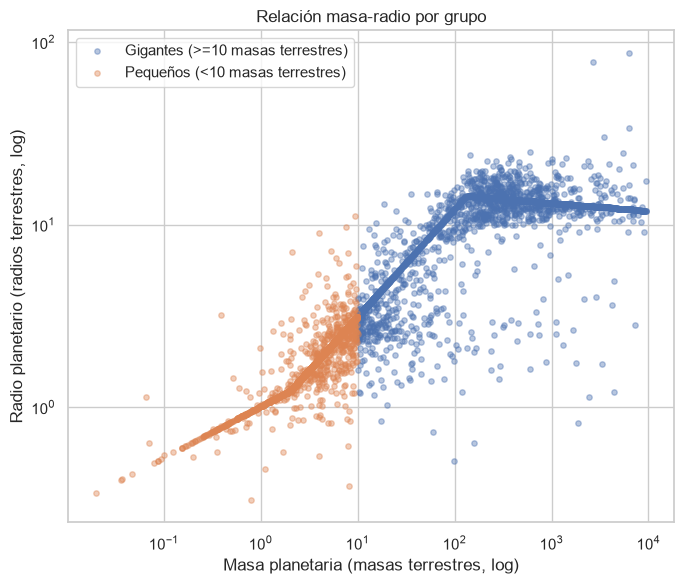

In [38]:
plt.figure(figsize=(7, 6))
for grupo, data in df_valid.groupby("grupo_masa"):
    plt.scatter(data["pl_bmasse"], data["pl_rade"], alpha=0.4, s=15, label=grupo)

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Masa planetaria (masas terrestres, log)")
plt.ylabel("Radio planetario (radios terrestres, log)")
plt.title("Relación masa-radio por grupo")
plt.legend()
plt.tight_layout()
plt.savefig("../images/relacion_masa_radio_separacion.png", dpi=150, bbox_inches="tight")
plt.show()